Реализация алгоритма Нидлмана - Вунша для приведенных строк

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
seq1 = 'ATGCAGCAGCAGCCA'
seq2 = 'ATATAT'

In [3]:
def needleman_wunsch_affine(seq1, seq2, match=3, mismatch=-3, gap_linear=None, gap_open=None, gap_extend=None):
    n, m = len(seq1), len(seq2)

    if gap_linear is not None:
        def gap_cost(k):
            return gap_linear * k
        model_type = "linear"
    else:
        def gap_cost(k):
            if k == 0:
                return 0
            return gap_open + gap_extend * (k - 1)
        model_type = "affine"

    score = np.zeros((n+1, m+1), dtype=int)
    trace = np.zeros((n+1, m+1), dtype=int)

    for i in range(1, n+1):
        score[i][0] = gap_cost(i)
        trace[i][0] = 2
    for j in range(1, m+1):
        score[0][j] = gap_cost(j)
        trace[0][j] = 3
    for i in range(1, n+1):
        for j in range(1, m+1):
            match_score = match if seq1[i-1] == seq2[j-1] else mismatch

            diag = score[i-1][j-1] + match_score

            up = score[i-1][j] + gap_cost(1)
            left = score[i][j-1] + gap_cost(1)

            max_score = max(diag, up, left)
            score[i][j] = max_score

            if max_score == diag:
                trace[i][j] = 1
            elif max_score == up:
                trace[i][j] = 2
            else:
                trace[i][j] = 3

    align1, align2 = [], []
    i, j = n, m

    while i > 0 or j > 0:
        if trace[i][j] == 1:
            align1.append(seq1[i-1])
            align2.append(seq2[j-1])
            i -= 1
            j -= 1
        elif trace[i][j] == 2:
            align1.append(seq1[i-1])
            align2.append('-')
            i -= 1
        else:
            align1.append('-')
            align2.append(seq2[j-1])
            j -= 1

    align1 = ''.join(reversed(align1))
    align2 = ''.join(reversed(align2))

    return score, align1, align2, model_type

ЛИНЕЙНАЯ МОДЕЛЬ
Итоговый Score: -30
Выравнивание:
ATGCAGCAGCAGCCA
AT-----A-TA---T

АФФИННАЯ МОДЕЛЬ
Итоговый Score: -32
Выравнивание:
ATGCAGCAGCAGCCA-
----------ATATAT



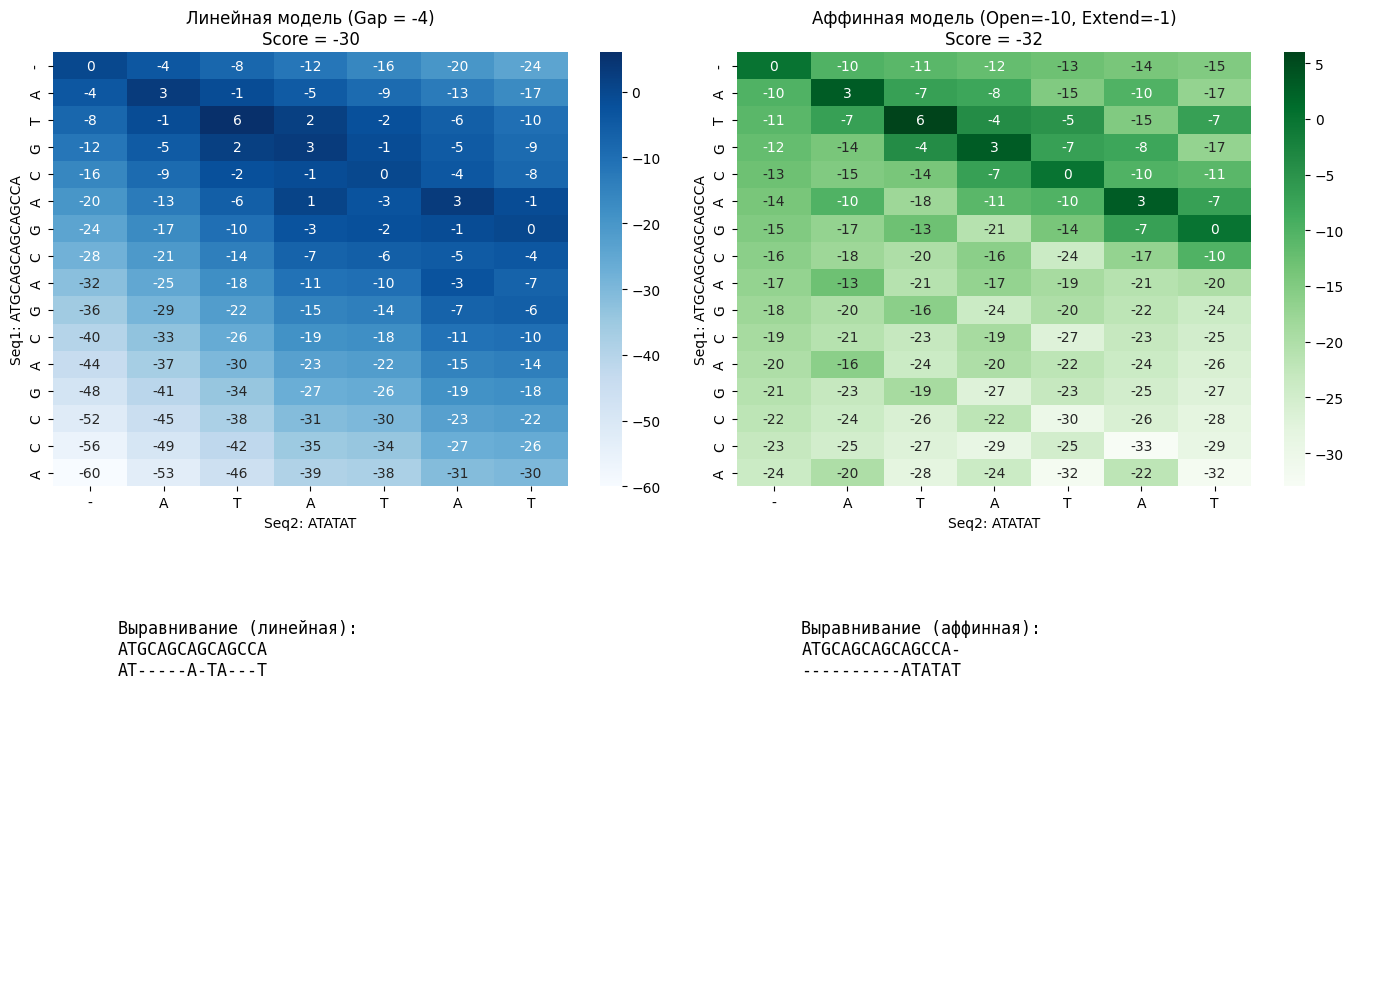

In [4]:
def visualize_matrices(score_linear, score_affine, align1_linear, align2_linear, align1_affine, align2_affine):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.heatmap(score_linear, annot=True, fmt='d', cmap='Blues',
                xticklabels=['-'] + list(seq2), yticklabels=['-'] + list(seq1),
                ax=axes[0, 0])
    axes[0, 0].set_title(f'Линейная модель (Gap = -4)\nScore = {score_linear[-1][-1]}')
    axes[0, 0].set_xlabel('Seq2: ATATAT')
    axes[0, 0].set_ylabel('Seq1: ATGCAGCAGCAGCCA')

    sns.heatmap(score_affine, annot=True, fmt='d', cmap='Greens',
                xticklabels=['-'] + list(seq2), yticklabels=['-'] + list(seq1),
                ax=axes[0, 1])
    axes[0, 1].set_title(f'Аффинная модель (Open=-10, Extend=-1)\nScore = {score_affine[-1][-1]}')
    axes[0, 1].set_xlabel('Seq2: ATATAT')
    axes[0, 1].set_ylabel('Seq1: ATGCAGCAGCAGCCA')

    axes[1, 0].text(0.1, 0.7, f"Выравнивание (линейная):\n{align1_linear}\n{align2_linear}",
                   fontfamily='monospace', fontsize=12, transform=axes[1, 0].transAxes)
    axes[1, 0].axis('off')

    axes[1, 1].text(0.1, 0.7, f"Выравнивание (аффинная):\n{align1_affine}\n{align2_affine}",
                   fontfamily='monospace', fontsize=12, transform=axes[1, 1].transAxes)
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.savefig('alignment_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

seq1 = "ATGCAGCAGCAGCCA"
seq2 = "ATATAT"

print("ЛИНЕЙНАЯ МОДЕЛЬ")
score_linear, align1_linear, align2_linear, _ = needleman_wunsch_affine(
    seq1, seq2, gap_linear=-4
)
print(f"Итоговый Score: {score_linear[-1][-1]}")
print(f"Выравнивание:\n{align1_linear}\n{align2_linear}")
print()

print("АФФИННАЯ МОДЕЛЬ")
score_affine, align1_affine, align2_affine, _ = needleman_wunsch_affine(
    seq1, seq2, gap_open=-10, gap_extend=-1
)
print(f"Итоговый Score: {score_affine[-1][-1]}")
print(f"Выравнивание:\n{align1_affine}\n{align2_affine}")
print()

visualize_matrices(score_linear, score_affine, align1_linear, align2_linear,
                  align1_affine, align2_affine)

В аффинной модели учитывается, что образование гэпа - редкое биологичсекое событие, а его продление - сильно менее редкое. Это отражено в штрафах. Длинные куски последовательности встречаются чаще, чем множество коротких, линейная модель этого не учитывает.